In [1]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine

engine = create_engine("sqlite:///../bluestock_mf.db")

nav = pd.read_sql("SELECT * FROM fact_nav", engine)
nav["date"] = pd.to_datetime(nav["date"])
nav = nav.sort_values(["amfi_code", "date"])
print(nav.shape)
nav.head()

(46000, 3)


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [2]:
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

print(nav["daily_return"].describe())
nav[["amfi_code", "date", "nav", "daily_return"]].head(10)

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


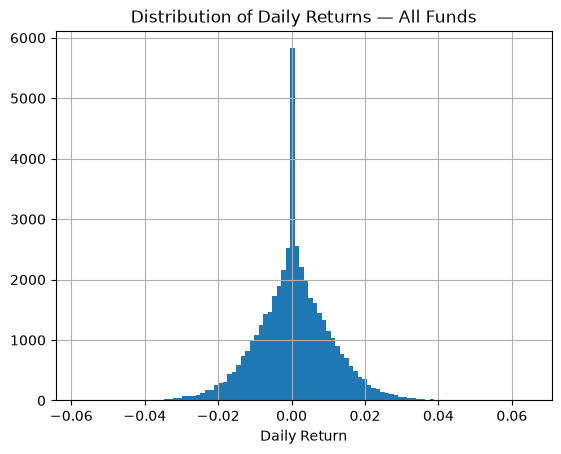

Any returns > 20% or < -20% (likely bad data)?
Empty DataFrame
Columns: [amfi_code, date, nav, daily_return]
Index: []


In [3]:
import matplotlib.pyplot as plt

nav["daily_return"].hist(bins=100)
plt.title("Distribution of Daily Returns — All Funds")
plt.xlabel("Daily Return")
plt.show()

print("Any returns > 20% or < -20% (likely bad data)?")
print(nav[(nav["daily_return"].abs() > 0.20)][["amfi_code", "date", "nav", "daily_return"]])

In [4]:
bench = pd.read_csv("../data/raw/10_benchmark_indices.csv")
print(bench["index_name"].unique())

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str


In [7]:
def calc_cagr(nav_series, dates, years):
    end_date = dates.max()
    target_start = end_date - pd.DateOffset(years=years)

    # Require actual history back to (or before) the target start date
    if dates.min() > target_start:
        return np.nan  # not enough history for this window

    window_mask = dates >= target_start
    window = nav_series[window_mask]
    window_dates = dates[window_mask]

    if len(window) < 2:
        return np.nan

    nav_start = window.iloc[0]
    nav_end = window.iloc[-1]
    n = (window_dates.iloc[-1] - window_dates.iloc[0]).days / 365.25
    if n <= 0:
        return np.nan
    return (nav_end / nav_start) ** (1 / n) - 1

cagr_results = []
for code, group in nav.groupby("amfi_code"):
    group = group.sort_values("date")
    cagr_1yr = calc_cagr(group["nav"], group["date"], 1)
    cagr_3yr = calc_cagr(group["nav"], group["date"], 3)
    cagr_5yr = calc_cagr(group["nav"], group["date"], 5)
    cagr_results.append({
        "amfi_code": code,
        "cagr_1yr": cagr_1yr,
        "cagr_3yr": cagr_3yr,
        "cagr_5yr": cagr_5yr,
    })

cagr_df = pd.DataFrame(cagr_results)
print(cagr_df.shape)
print("\nNull counts per column:")
print(cagr_df.isnull().sum())
cagr_df.head(10)

(40, 4)

Null counts per column:
amfi_code     0
cagr_1yr      0
cagr_3yr      0
cagr_5yr     40
dtype: int64


,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,-0.022258,0.012924,NaN
1,100025,0.037076,0.039155,NaN
2,100033,0.532772,0.324340,NaN
3,101206,0.479638,0.289602,NaN
4,101207,-0.240003,-0.041515,NaN
5,101208,0.072418,0.063143,NaN
6,102885,0.202229,0.196624,NaN
7,102886,-0.168080,-0.007672,NaN
8,102887,0.135930,0.255497,NaN
9,118632,0.340079,0.226466,NaN


In [8]:
Rf_annual = 0.065
Rf_daily = Rf_annual / 252  # convert annual risk-free rate to daily

sharpe_results = []
for code, group in nav.groupby("amfi_code"):
    returns = group["daily_return"].dropna()
    excess_return = returns.mean() - Rf_daily
    std_return = returns.std()
    sharpe = (excess_return / std_return) * np.sqrt(252)
    sharpe_results.append({"amfi_code": code, "sharpe_ratio": sharpe})

sharpe_df = pd.DataFrame(sharpe_results)
sharpe_df["sharpe_rank"] = sharpe_df["sharpe_ratio"].rank(ascending=False)
sharpe_df = sharpe_df.sort_values("sharpe_ratio", ascending=False)

print(sharpe_df.shape)
sharpe_df.head(10)

(40, 3)


,amfi_code,sharpe_ratio,sharpe_rank
34,148567,1.448291,1.0
30,120843,1.306744,2.0
36,148569,1.234930,3.0
19,119551,1.208267,4.0
25,120505,1.180101,5.0
38,149323,1.132122,6.0
2,100033,1.093699,7.0
9,118632,1.081659,8.0
3,101206,1.027213,9.0
24,120504,1.026524,10.0


In [9]:
sortino_results = []
for code, group in nav.groupby("amfi_code"):
    returns = group["daily_return"].dropna()
    excess_return = returns.mean() - Rf_daily

    downside_returns = returns[returns < 0]
    downside_std = downside_returns.std()

    sortino = (excess_return / downside_std) * np.sqrt(252)
    sortino_results.append({"amfi_code": code, "sortino_ratio": sortino})

sortino_df = pd.DataFrame(sortino_results)
sortino_df["sortino_rank"] = sortino_df["sortino_ratio"].rank(ascending=False)
sortino_df = sortino_df.sort_values("sortino_ratio", ascending=False)

print(sortino_df.shape)
sortino_df.head(10)

(40, 3)


,amfi_code,sortino_ratio,sortino_rank
34,148567,2.385644,1.0
30,120843,2.364320,2.0
36,148569,2.146914,3.0
19,119551,2.140267,4.0
25,120505,2.029353,5.0
38,149323,1.875101,6.0
9,118632,1.850133,7.0
2,100033,1.829134,8.0
24,120504,1.805294,9.0
3,101206,1.799563,10.0


In [12]:
from scipy import stats

bench = pd.read_csv("../data/raw/10_benchmark_indices.csv")
bench["date"] = pd.to_datetime(bench["date"])

nifty100 = bench[bench["index_name"] == "NIFTY100"].sort_values("date").copy()
nifty100["bench_return"] = nifty100["close_value"].pct_change()

print(nifty100.shape)
nifty100.head()

(1150, 4)


,date,index_name,close_value,bench_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [13]:
alpha_beta_results = []

for code, group in nav.groupby("amfi_code"):
    fund_returns = group[["date", "daily_return"]].dropna()
    merged = fund_returns.merge(nifty100[["date", "bench_return"]], on="date", how="inner").dropna()

    if len(merged) < 30:
        alpha_beta_results.append({"amfi_code": code, "alpha": np.nan, "beta": np.nan, "r_value": np.nan})
        continue

    slope, intercept, r_value, p_value, std_err = stats.linregress(
        merged["bench_return"], merged["daily_return"]
    )

    alpha_annualized = intercept * 252
    beta = slope

    alpha_beta_results.append({
        "amfi_code": code,
        "alpha": alpha_annualized,
        "beta": beta,
        "r_value": r_value,
    })

alpha_beta_df = pd.DataFrame(alpha_beta_results)
print(alpha_beta_df.shape)
alpha_beta_df.head(10)

(40, 4)


,amfi_code,alpha,beta,r_value
0,100016,0.037476,-0.058268,-0.051624
1,100025,0.042818,0.001158,0.003823
2,100033,0.271954,0.005104,0.003474
3,101206,0.213998,0.021086,0.018656
4,101207,0.108971,-0.065289,-0.032621
5,101208,0.060861,0.000267,0.006788
6,102885,0.170488,-0.019487,-0.019567
7,102886,0.028969,-0.042125,-0.029940
8,102887,0.162113,0.016683,0.013645
9,118632,0.218294,-0.008354,-0.007610


In [15]:
drawdown_results = []

for code, group in nav.groupby("amfi_code"):
    group = group.sort_values("date").copy()
    group["running_max"] = group["nav"].cummax()
    group["drawdown"] = group["nav"] / group["running_max"] - 1

    max_dd = group["drawdown"].min()
    trough_idx = group["drawdown"].idxmin()
    trough_date = group.loc[trough_idx, "date"]

    # Find the peak date before the trough (the start of this drawdown)
    peak_date = group.loc[group.loc[:trough_idx, "nav"].idxmax(), "date"]

    drawdown_results.append({
        "amfi_code": code,
        "max_drawdown_pct": max_dd,
        "peak_date": peak_date,
        "trough_date": trough_date,
    })

drawdown_df = pd.DataFrame(drawdown_results)
print(drawdown_df.shape)
drawdown_df.sort_values("max_drawdown_pct").head(10)

(40, 4)


,amfi_code,max_drawdown_pct,peak_date,trough_date
22,119599,-0.525742,2023-01-17,2025-10-28
17,119095,-0.516778,2025-05-22,2026-05-11
4,101207,-0.354469,2024-11-21,2026-05-11
39,149324,-0.311719,2024-05-03,2025-01-03
21,119598,-0.287060,2024-08-28,2025-05-14
7,102886,-0.280011,2025-01-07,2026-04-27
0,100016,-0.247344,2022-03-30,2022-09-15
29,120842,-0.240035,2023-11-09,2024-10-17
11,118634,-0.233449,2025-04-09,2026-02-20
15,119093,-0.217514,2022-02-24,2023-05-22


In [16]:
# Pull expense ratio from fact_performance (already in your DB)
perf = pd.read_sql("SELECT amfi_code, expense_ratio_pct FROM fact_performance", engine)

# Merge all components together
scorecard = cagr_df[["amfi_code", "cagr_3yr"]].merge(sharpe_df[["amfi_code", "sharpe_ratio"]], on="amfi_code")
scorecard = scorecard.merge(alpha_beta_df[["amfi_code", "alpha"]], on="amfi_code")
scorecard = scorecard.merge(perf, on="amfi_code")
scorecard = scorecard.merge(drawdown_df[["amfi_code", "max_drawdown_pct"]], on="amfi_code")

print(scorecard.shape)
scorecard.head(10)

(40, 6)


,amfi_code,cagr_3yr,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown_pct
0,100016,0.012924,-0.201517,0.037476,1.55,-0.247344
1,100025,0.039155,-0.567095,0.042818,0.56,-0.043083
2,100033,0.324340,1.093699,0.271954,1.38,-0.162172
3,101206,0.289602,1.027213,0.213998,1.60,-0.112916
4,101207,-0.041515,0.162661,0.108971,1.53,-0.354469
5,101208,0.063143,-0.815567,0.060861,0.79,-0.001622
6,102885,0.196624,0.817099,0.170488,1.57,-0.108599
7,102886,-0.007672,-0.205832,0.028969,1.51,-0.280011
8,102887,0.255497,0.619518,0.162113,1.64,-0.215398
9,118632,0.226466,1.081659,0.218294,1.51,-0.174141


In [17]:
# Rank each metric 1 = best. For expense_ratio and max_drawdown, LOWER is better (inverse), so rank ascending=True.
# For return, sharpe, alpha, HIGHER is better, so rank ascending=False.

scorecard["rank_return"] = scorecard["cagr_3yr"].rank(ascending=False)
scorecard["rank_sharpe"] = scorecard["sharpe_ratio"].rank(ascending=False)
scorecard["rank_alpha"] = scorecard["alpha"].rank(ascending=False)
scorecard["rank_expense"] = scorecard["expense_ratio_pct"].rank(ascending=True)   # lower expense = better = rank 1
scorecard["rank_maxdd"] = scorecard["max_drawdown_pct"].rank(ascending=False)      # max_drawdown is negative; less negative (closer to 0) = better = rank 1

# Convert each rank to a 0-100 "sub-score" (best rank = 100, worst = ~0)
n = len(scorecard)
for col in ["rank_return", "rank_sharpe", "rank_alpha", "rank_expense", "rank_maxdd"]:
    score_col = col.replace("rank_", "score_")
    scorecard[score_col] = 100 * (n - scorecard[col]) / (n - 1)

scorecard["fund_scorecard"] = (
    0.30 * scorecard["score_return"] +
    0.25 * scorecard["score_sharpe"] +
    0.20 * scorecard["score_alpha"] +
    0.15 * scorecard["score_expense"] +
    0.10 * scorecard["score_maxdd"]
)

scorecard = scorecard.sort_values("fund_scorecard", ascending=False)
print(scorecard[["amfi_code", "fund_scorecard"]].head(10))
print("\nScore range:", scorecard["fund_scorecard"].min(), "-", scorecard["fund_scorecard"].max())

    amfi_code  fund_scorecard
34     148567       85.897436
25     120505       81.794872
30     120843       81.538462
2      100033       80.256410
24     120504       79.487179
16     119094       76.410256
19     119551       74.166667
36     148569       73.012821
3      101206       67.371795
21     119598       66.538462

Score range: 12.115384615384617 - 85.89743589743588


In [18]:
top5_codes = scorecard.head(5)["amfi_code"].tolist()
print(top5_codes)

nifty50 = bench[bench["index_name"] == "NIFTY50"].sort_values("date").copy()
nifty50["bench_return"] = nifty50["close_value"].pct_change()

# Restrict everything to the last 3 years of available data
end_date = nav["date"].max()
start_date = end_date - pd.DateOffset(years=3)

nifty50_3yr = nifty50[nifty50["date"] >= start_date].copy()
nifty100_3yr = nifty100[nifty100["date"] >= start_date].copy()

[148567, 120505, 120843, 100033, 120504]


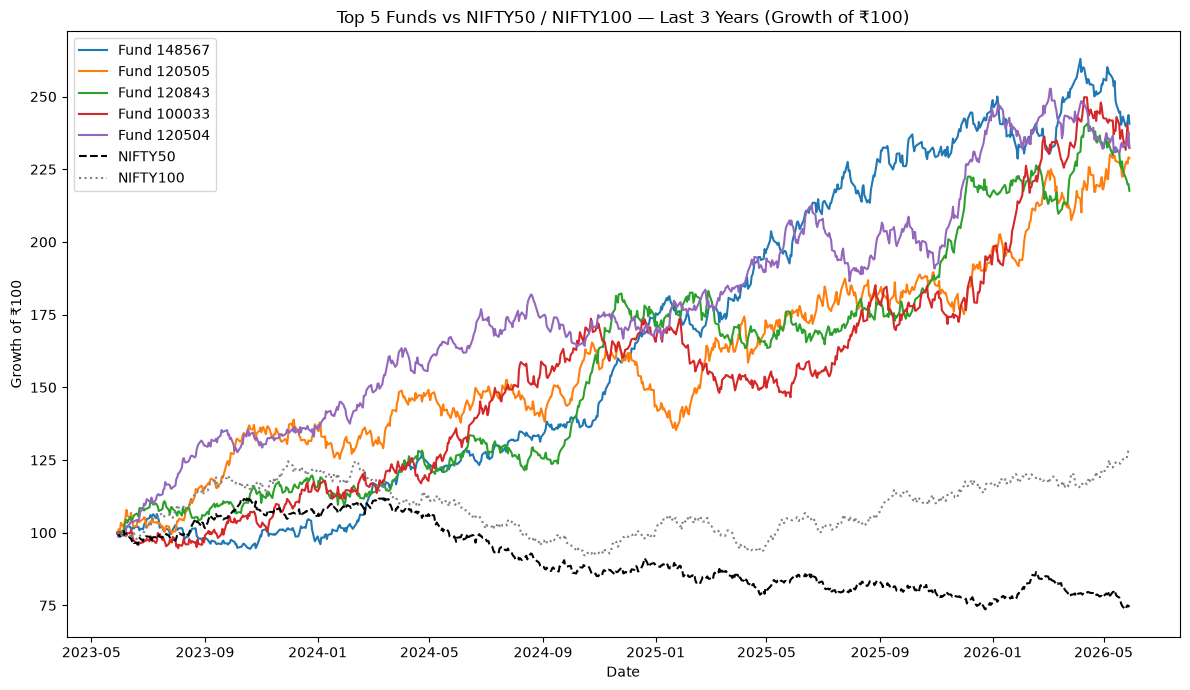

In [19]:
plt.figure(figsize=(12, 7))

for code in top5_codes:
    fund_data = nav[(nav["amfi_code"] == code) & (nav["date"] >= start_date)].sort_values("date").copy()
    fund_data["cumulative"] = fund_data["nav"] / fund_data["nav"].iloc[0] * 100
    plt.plot(fund_data["date"], fund_data["cumulative"], label=f"Fund {code}")

nifty50_cum = nifty50_3yr["close_value"] / nifty50_3yr["close_value"].iloc[0] * 100
plt.plot(nifty50_3yr["date"], nifty50_cum, label="NIFTY50", linestyle="--", color="black")

nifty100_cum = nifty100_3yr["close_value"] / nifty100_3yr["close_value"].iloc[0] * 100
plt.plot(nifty100_3yr["date"], nifty100_cum, label="NIFTY100", linestyle=":", color="gray")

plt.title("Top 5 Funds vs NIFTY50 / NIFTY100 — Last 3 Years (Growth of ₹100)")
plt.xlabel("Date")
plt.ylabel("Growth of ₹100")
plt.legend()
plt.tight_layout()
plt.savefig("../benchmark_comparison_chart.png", dpi=150)
plt.show()

In [20]:
tracking_errors = []
for code in top5_codes:
    fund_data = nav[(nav["amfi_code"] == code) & (nav["date"] >= start_date)][["date", "daily_return"]].dropna()
    merged = fund_data.merge(nifty50_3yr[["date", "bench_return"]], on="date", how="inner").dropna()
    diff = merged["daily_return"] - merged["bench_return"]
    tracking_error = diff.std() * np.sqrt(252)
    tracking_errors.append({"amfi_code": code, "tracking_error_vs_nifty50": tracking_error})

te_df = pd.DataFrame(tracking_errors)
te_df

,amfi_code,tracking_error_vs_nifty50
0,148567,0.191817
1,120505,0.228311
2,120843,0.204946
3,100033,0.228081
4,120504,0.188360


In [21]:
scorecard.to_csv("../fund_scorecard.csv", index=False)
alpha_beta_df.to_csv("../alpha_beta.csv", index=False)
print("Saved.")

Saved.
